In [4]:
!pip install pandas numpy gymnasium stable-baselines3[extra] torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118
!pip install huggingface_hub transformers accelerate # For LLM
!pip install python-jsonrpc-server # Simple option for MCP server logic later

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 7.1 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 28.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.

In [8]:
!pip install prophet pmdarima matplotlib seaborn statsmodels pandas numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 23.0 MB/s eta 0:00:00a 0:00:01


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

In [10]:
import pandas as pd
import numpy as np
import os

# --- Configuration ---
DRIVE_PROJECT_PATH = '/kaggle/input/m5-forecasting-accuracy/'
OUTPUT_PATH = '/kaggle/working/'
INPUT_CSV_PATH = os.path.join(DRIVE_PROJECT_PATH, 'sales_train_evaluation.csv')
OUTPUT_TRAIN_PATH = os.path.join(OUTPUT_PATH, 'demand_train_single_product.npy')
OUTPUT_TEST_PATH = os.path.join(OUTPUT_PATH, 'demand_test_single_product.npy')
PROCESSED_DATA_EXISTS = os.path.exists(OUTPUT_TRAIN_PATH) and os.path.exists(OUTPUT_TEST_PATH)

# 3. Define Parameters
PRODUCT_ID_TO_EXTRACT = 'FOODS_3_090_CA_3_evaluation' # Example Product ID - CHOOSE ONE YOU LIKE
TRAIN_DAYS = 1500
TOTAL_DAYS = 1941 # Based on d_1 to d_1941 in sales_train_evaluation.csv

# --- Step 1: Load and Preprocess ---

if not PROCESSED_DATA_EXISTS:
    print(f"Processed data not found. Loading and processing {INPUT_CSV_PATH}...")

    # --- Action: Load specific columns using Pandas ---
    print("Generating column list...")
    # Define identifier columns
    id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id']
    # Define sales day columns (d_1 to d_1941)
    sales_cols = [f'd_{i}' for i in range(1, TOTAL_DAYS + 1)]
    # Combine columns to load
    cols_to_load = id_cols + sales_cols
    print(f"Loading {len(cols_to_load)} columns...")

    # Load the CSV with only necessary columns
    try:
        # Using Pandas as requested in the prompt description
        df = pd.read_csv(INPUT_CSV_PATH, usecols=cols_to_load)
        print(f"Loaded DataFrame shape: {df.shape}")
    except FileNotFoundError:
        print(f"ERROR: Input CSV file not found at {INPUT_CSV_PATH}")
        print("Please ensure the file exists in your Google Drive project folder and the path is correct.")
        # Exit or raise an error if the file isn't found
        raise
    except Exception as e:
        print(f"An error occurred during CSV loading: {e}")
        raise

    # --- Action: Select ONE specific product time series ---
    print(f"Filtering for product_id: {PRODUCT_ID_TO_EXTRACT}")
    product_df = df[df['id'] == PRODUCT_ID_TO_EXTRACT].copy() # Use .copy() to avoid SettingWithCopyWarning

    if product_df.empty:
        print(f"ERROR: Product ID '{PRODUCT_ID_TO_EXTRACT}' not found in the data.")
        # Optionally, list some available IDs
        print("Available IDs sample:", df['id'].head().tolist())
        raise ValueError(f"Product ID {PRODUCT_ID_TO_EXTRACT} not found.")
    else:
        print(f"Found product. Shape: {product_df.shape}")


    # --- Action: Extract the sales values into a NumPy array ---
    print("Extracting sales values...")
    # Select only the 'd_' columns and get the values as a NumPy array
    # .iloc[0] selects the first (and only) row after filtering
    # .values converts the resulting Pandas Series to a NumPy array
    demand_raw = product_df[sales_cols].iloc[0].values
    print(f"Raw demand array shape: {demand_raw.shape}")
    print(f"Raw demand data type: {demand_raw.dtype}") # Often 'object' if mixed types, or int64

    # --- Action: Handle potential missing values ---
    # M5 data might have NaNs implicitly if loaded poorly, but typically it's numeric.
    # However, sales might start later, represented by 0s. Let's ensure correct type and handle potential NaNs just in case.
    # Convert to a numeric type (float first to handle potential NaNs, then int if desired)
    # If NaNs occurred (e.g., before product launch), fill with 0
    demand_numeric = pd.to_numeric(demand_raw, errors='coerce') # Convert non-numeric to NaN
    demand_filled = np.nan_to_num(demand_numeric, nan=0.0)     # Replace NaN with 0.0
    demand_final = demand_filled.astype(np.int64)              # Convert to integer (optional)

    print(f"Processed demand array shape: {demand_final.shape}")
    print(f"Processed demand data type: {demand_final.dtype}")
    # print("Sample demand data (first 50 days):", demand_final[:50]) # Uncomment to inspect

    # --- Action: Split the demand data ---
    print(f"Splitting data into train ({TRAIN_DAYS} days) and test ({TOTAL_DAYS - TRAIN_DAYS} days)...")
    if TRAIN_DAYS >= TOTAL_DAYS:
        print("Warning: Train days is equal to or greater than total days. Test set will be empty.")
        demand_train = demand_final[:TRAIN_DAYS]
        demand_test = np.array([], dtype=demand_final.dtype) # Empty array
    else:
        demand_train = demand_final[:TRAIN_DAYS]
        demand_test = demand_final[TRAIN_DAYS:]

    print(f"Train data shape: {demand_train.shape}")
    print(f"Test data shape: {demand_test.shape}")

    # --- Action: Save the processed demand arrays ---
    print(f"Saving processed data to {DRIVE_PROJECT_PATH}...")
    # Create directory if it doesn't exist
    os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)

    np.save(OUTPUT_TRAIN_PATH, demand_train)
    np.save(OUTPUT_TEST_PATH, demand_test)
    print(f"Saved train data to: {OUTPUT_TRAIN_PATH}")
    print(f"Saved test data to: {OUTPUT_TEST_PATH}")

else:
    print("Processed data files already exist. Loading from .npy files...")
    demand_train = np.load(OUTPUT_TRAIN_PATH)
    demand_test = np.load(OUTPUT_TEST_PATH)
    print(f"Loaded train data shape: {demand_train.shape}")
    print(f"Loaded test data shape: {demand_test.shape}")

# --- Verification (Optional) ---
print("\n--- Data Ready ---")
print(f"Train data sample (first 10): {demand_train[:10]}")
print(f"Test data sample (first 10): {demand_test[:10]}")

Processed data files already exist. Loading from .npy files...
Loaded train data shape: (1500,)
Loaded test data shape: (441,)

--- Data Ready ---
Train data sample (first 10): [108 132 102 120 106 123 279 175 186 120]
Test data sample (first 10): [  0   0   0 166 265 257 189  74  85  74]


Total Train Days: 1500
Test Horizon: 441
Validation will use train data up to day 1031
Validation target period: days 1031 to 1500

--- Loading Data ---
Loaded train data shape: (1500,)
Loaded test data shape: (441,)
Loaded calendar data shape: (1969, 14)

--- Stationarity Analysis (ADF Test) ---
ADF Test for: Original Training Data
   Test Statistic: -3.4262
   p-value: 0.0101
   Num Lags Used: 24
   Critical Values:
      1%: -3.4348
      5%: -2.8635
      10%: -2.5678
   Conclusion: Likely Stationary (Reject H0)
ADF Test for: First Difference
   Test Statistic: -9.6289
   p-value: 0.0000
   Num Lags Used: 24
   Critical Values:
      1%: -3.4348
      5%: -2.8635
      10%: -2.5678
   Conclusion: Likely Stationary (Reject H0)

Suggested differencing order (d) for ARIMA based on ADF: 0

--- ACF and PACF Plots ---


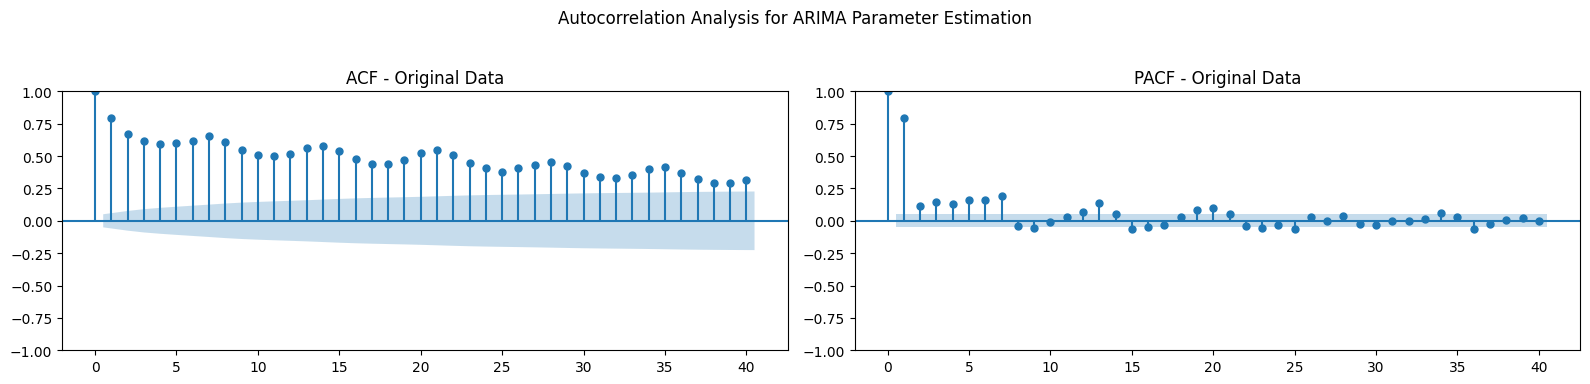

Hints for ARIMA (p, q) from plots:
 - Look at PACF for AR order (p): Cuts off after lag p.
 - Look at ACF for MA order (q): Cuts off after lag q.
   (If plots tail off gradually, suggests mixed ARMA process)

--- Preparing Validation Split (with Gap) ---
Validation Training Data: 1031 points (ends 2013-11-24)
Gap Period: 28 days
Validation Target Data: 441 points (starts 2013-12-23)

--- Prophet Model ---
Prepared 162 holiday/event instances for Prophet.
Running Prophet Validation...


04:21:46 - cmdstanpy - INFO - Chain [1] start processing
04:21:46 - cmdstanpy - INFO - Chain [1] done processing
04:21:46 - cmdstanpy - INFO - Chain [1] start processing


Prophet Validation MAE: 90.7245
Prophet Validation RMSE: 115.9884

Training Prophet on full training data...


04:21:46 - cmdstanpy - INFO - Chain [1] done processing



--- ARIMA Model ---
Running ARIMA Validation (using auto_arima)...
Auto ARIMA Validation Best Order: (5, 0, 2)
ARIMA Validation MAE: 70.6928
ARIMA Validation RMSE: 89.4569

Training ARIMA on full training data (using auto_arima)...
Auto ARIMA Final Best Order: (5, 0, 1)

--- Final Evaluation on Test Set ---
Prophet Test MAE: 78.9147
Prophet Test RMSE: 93.4564
ARIMA Test MAE: 52.9881
ARIMA Test RMSE: 68.0817

--- Plotting Forecasts vs Actuals (Test Set) ---


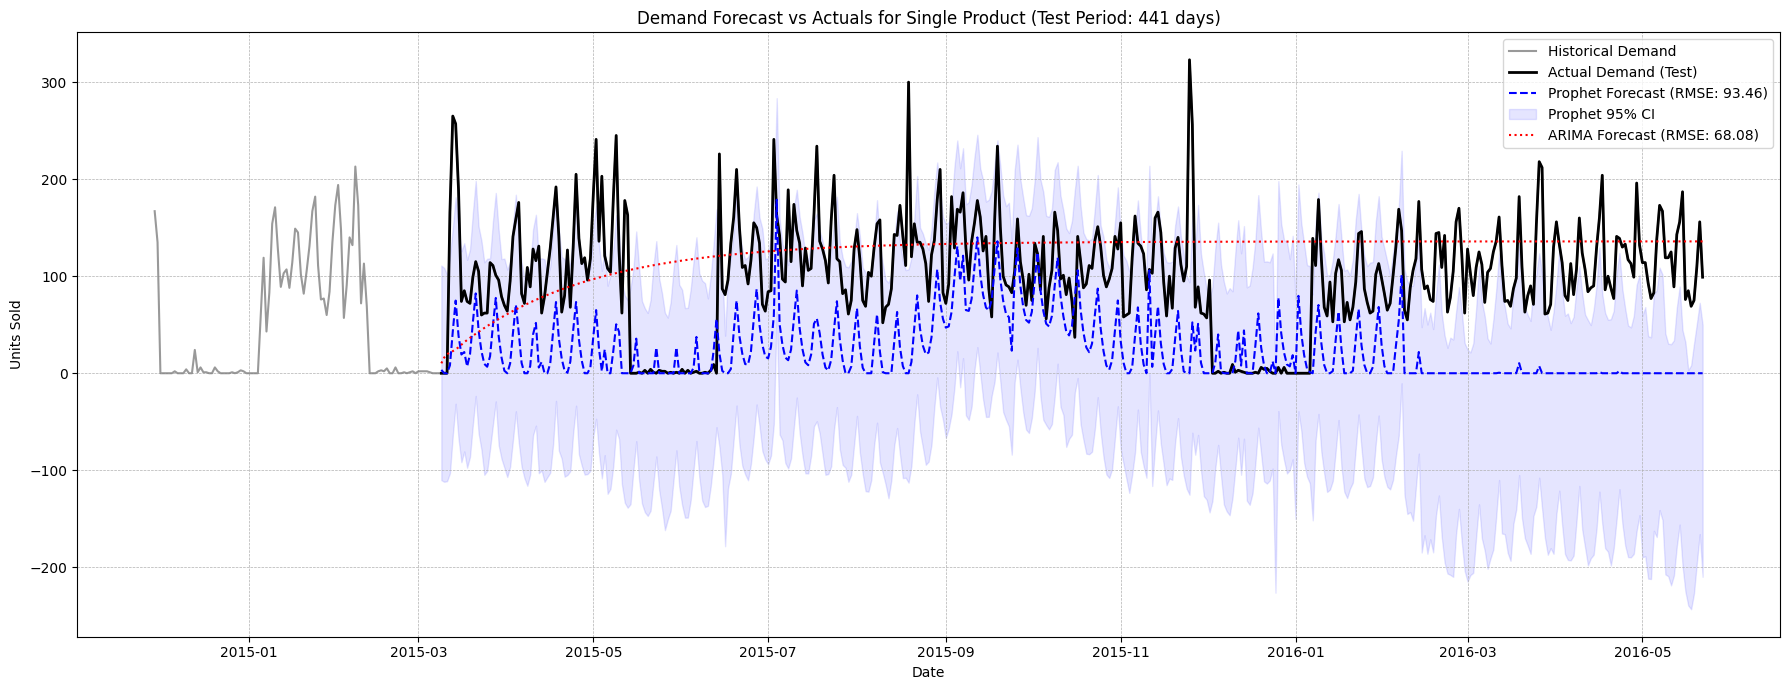

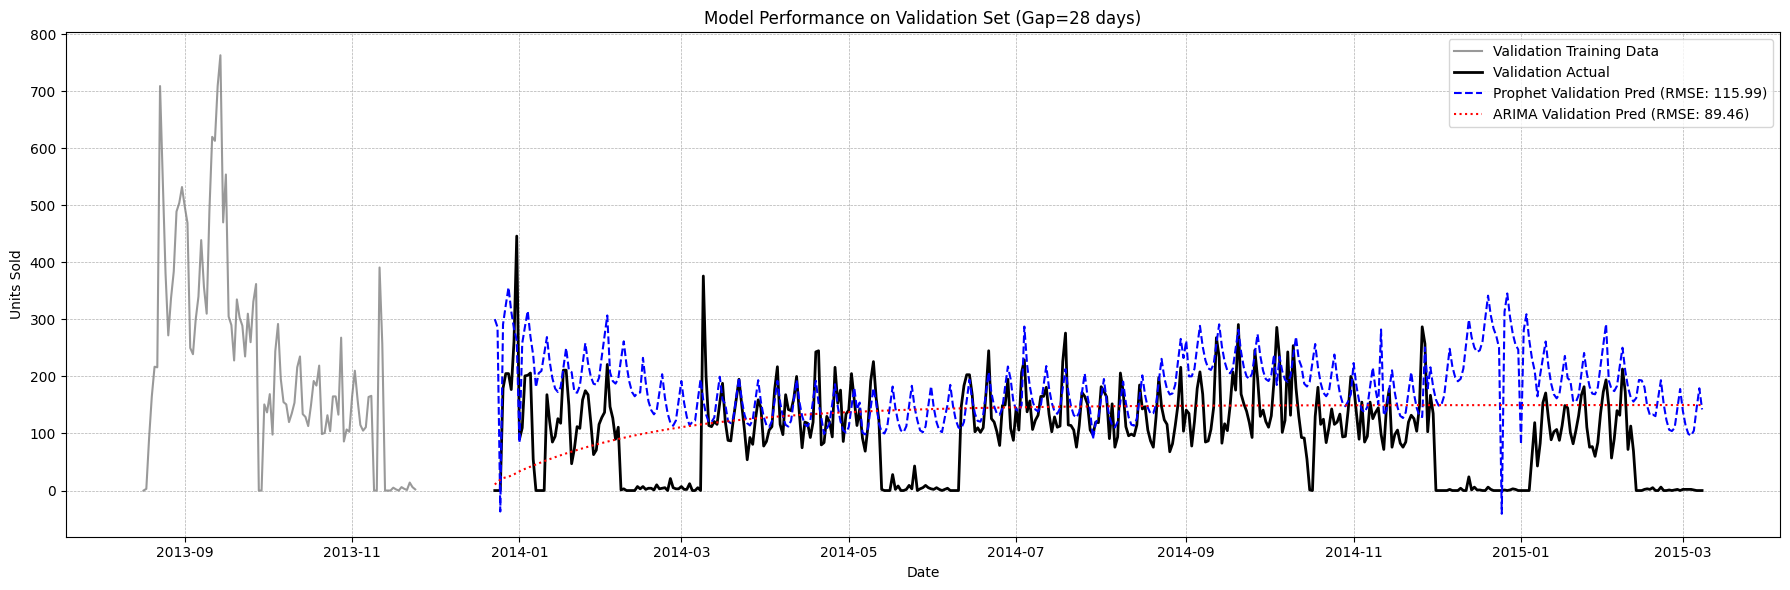

In [12]:
warnings.filterwarnings("ignore")

# --- Configuration ---

INPUT_TRAIN_PATH = os.path.join(OUTPUT_PATH, 'demand_train_single_product.npy')
INPUT_TEST_PATH = os.path.join(OUTPUT_PATH, 'demand_test_single_product.npy')
CALENDAR_CSV_PATH = os.path.join(DRIVE_PROJECT_PATH, 'calendar.csv') # Needed for dates and Prophet holidays


FORECAST_HORIZON = TOTAL_DAYS - TRAIN_DAYS # Length of the test set

# Validation Parameters
VALIDATION_SPLIT_POINT = TRAIN_DAYS - FORECAST_HORIZON - 28 # Where validation data starts (e.g., predict last 28 days of train)
# Example: Train = 1500 days, Test = 413 days.
# Let's validate on roughly a month (28 days) before the test set starts.
# Validation data will be: demand_train[1472:1500] (28 days)
# Training data for validation model: demand_train[0:1472]
# Ensure VAL_SPLIT_POINT is reasonable (not too close to beginning)
if VALIDATION_SPLIT_POINT < 50: # Need some data to train on
    print("Warning: Validation split point is very early. Adjusting.")
    VALIDATION_SPLIT_POINT = max(50, TRAIN_DAYS // 2) # Adjust if needed

print(f"Total Train Days: {TRAIN_DAYS}")
print(f"Test Horizon: {FORECAST_HORIZON}")
print(f"Validation will use train data up to day {VALIDATION_SPLIT_POINT}")
print(f"Validation target period: days {VALIDATION_SPLIT_POINT} to {TRAIN_DAYS}")


# --- Load Preprocessed Data and Calendar ---

print("\n--- Loading Data ---")
try:
    demand_train = np.load(INPUT_TRAIN_PATH)
    demand_test = np.load(INPUT_TEST_PATH)
    calendar_df = pd.read_csv(CALENDAR_CSV_PATH, parse_dates=['date'])
    print(f"Loaded train data shape: {demand_train.shape}")
    print(f"Loaded test data shape: {demand_test.shape}")
    print(f"Loaded calendar data shape: {calendar_df.shape}")
except FileNotFoundError as e:
    print(f"ERROR: Could not find data files: {e}")
    print("Please ensure demand_train*.npy, demand_test*.npy, and calendar.csv exist.")
    raise

# --- Create Date Ranges ---
# Get the dates corresponding to our train and test periods from calendar_df
if len(calendar_df) < TOTAL_DAYS_EVAL:
     print(f"Warning: Calendar CSV has only {len(calendar_df)} rows, less than expected {TOTAL_DAYS_EVAL} days.")
     # Adjust if calendar is shorter than expected sales data length
     TOTAL_DAYS_ADJ = len(calendar_df)
     TRAIN_DAYS = min(TRAIN_DAYS, TOTAL_DAYS_ADJ - FORECAST_HORIZON) # Adjust train days if needed
     print(f"Adjusted Total Days: {TOTAL_DAYS_ADJ}, Adjusted Train Days: {TRAIN_DAYS}")
else:
    TOTAL_DAYS_ADJ = TOTAL_DAYS_EVAL

dates = calendar_df['date'][:TOTAL_DAYS_ADJ]
train_dates = dates[:TRAIN_DAYS]
test_dates = dates[TRAIN_DAYS:TRAIN_DAYS + len(demand_test)] # Ensure correct length

if len(train_dates) != len(demand_train):
    raise ValueError(f"Mismatch: Train dates ({len(train_dates)}) vs train demand ({len(demand_train)})")
if len(test_dates) != len(demand_test):
    print(f"Warning: Test dates ({len(test_dates)}) vs test demand ({len(demand_test)}) mismatch. Truncating test demand.")
    # This might happen if calendar ends before d_1941, but sales_train_evaluation went further
    demand_test = demand_test[:len(test_dates)]
    FORECAST_HORIZON = len(demand_test) # Update horizon


# Combine into Pandas Series for easier handling
ts_train_pd = pd.Series(demand_train, index=train_dates, name='demand')
ts_test_pd = pd.Series(demand_test, index=test_dates, name='demand')
ts_full_pd = pd.concat([ts_train_pd, ts_test_pd])

# --- Stationarity Analysis ---
print("\n--- Stationarity Analysis (ADF Test) ---")

def perform_adf_test(series, series_name):
    """Performs ADF test and prints results."""
    result = adfuller(series.dropna()) # Drop NA if differencing created them
    print(f'ADF Test for: {series_name}')
    print(f'   Test Statistic: {result[0]:.4f}')
    print(f'   p-value: {result[1]:.4f}')
    print(f'   Num Lags Used: {result[2]}')
    print(f'   Critical Values:')
    for key, value in result[4].items():
        print(f'      {key}: {value:.4f}')
    if result[1] <= 0.05:
        print(f'   Conclusion: Likely Stationary (Reject H0)')
        return True
    else:
        print(f'   Conclusion: Likely Non-Stationary (Fail to reject H0)')
        return False

# Test original data
is_stationary_orig = perform_adf_test(ts_train_pd, "Original Training Data")

# Test first difference
ts_train_diff1 = ts_train_pd.diff().dropna()
is_stationary_diff1 = perform_adf_test(ts_train_diff1, "First Difference")
arima_d = 0 if is_stationary_orig else 1 # Start guessing the 'd' parameter

# Test second difference (only if first difference wasn't stationary)
if not is_stationary_orig and not is_stationary_diff1:
    ts_train_diff2 = ts_train_diff1.diff().dropna()
    is_stationary_diff2 = perform_adf_test(ts_train_diff2, "Second Difference")
    if is_stationary_diff2:
        arima_d = 2
else:
    is_stationary_diff2 = False # Not tested or not stationary

print(f"\nSuggested differencing order (d) for ARIMA based on ADF: {arima_d}")

# --- ACF/PACF Plots (on the stationary series) ---
print("\n--- ACF and PACF Plots ---")
stationary_series_for_plots = ts_train_pd
plot_title_suffix = "Original Data"
if arima_d == 1:
    stationary_series_for_plots = ts_train_diff1
    plot_title_suffix = "First Difference"
elif arima_d == 2:
    stationary_series_for_plots = ts_train_diff2
    plot_title_suffix = "Second Difference"

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(stationary_series_for_plots, ax=axes[0], lags=40, title=f'ACF - {plot_title_suffix}')
plot_pacf(stationary_series_for_plots, ax=axes[1], lags=40, title=f'PACF - {plot_title_suffix}', method='ywm') # 'ywm' is often preferred
plt.suptitle("Autocorrelation Analysis for ARIMA Parameter Estimation")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("Hints for ARIMA (p, q) from plots:")
print(" - Look at PACF for AR order (p): Cuts off after lag p.")
print(" - Look at ACF for MA order (q): Cuts off after lag q.")
print("   (If plots tail off gradually, suggests mixed ARMA process)")

# --- Validation Split with Gap ---
print("\n--- Preparing Validation Split (with Gap) ---")

# Define the gap period
# The validation training data ends at VALIDATION_SPLIT_POINT
# The validation target data starts after the gap
# Let's use a 28-day gap as initially planned
GAP_DAYS = 28
validation_train_end_index = VALIDATION_SPLIT_POINT
validation_target_start_index = validation_train_end_index + GAP_DAYS

if validation_target_start_index >= TRAIN_DAYS:
    print("Warning: Gap is too large, validation target period is empty or invalid. Reducing gap.")
    # Reduce gap to have at least some validation days (e.g., 14 days)
    MIN_VAL_DAYS = 14
    GAP_DAYS = max(0, TRAIN_DAYS - validation_train_end_index - MIN_VAL_DAYS)
    validation_target_start_index = validation_train_end_index + GAP_DAYS
    print(f"Adjusted Gap: {GAP_DAYS} days")

# Extract validation training and target sets
train_val = ts_train_pd[:validation_train_end_index]
# The actual values we want to predict in validation
validation_target = ts_train_pd[validation_target_start_index:]
validation_target_dates = ts_train_pd.index[validation_target_start_index:]
validation_horizon = len(validation_target)

print(f"Validation Training Data: {len(train_val)} points (ends {train_val.index.max().date()})")
print(f"Gap Period: {GAP_DAYS} days")
print(f"Validation Target Data: {len(validation_target)} points (starts {validation_target.index.min().date()})")


# --- Prophet Model ---
print("\n--- Prophet Model ---")

# Prepare holidays for Prophet
holidays = calendar_df[calendar_df['event_name_1'].notna() | calendar_df['event_name_2'].notna()][['date', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']].copy()
holidays['event_name_1'] = holidays['event_name_1'].fillna('')
holidays['event_name_2'] = holidays['event_name_2'].fillna('')
holidays['holiday'] = holidays['event_name_1'] + holidays['event_name_2'] # Combine potential events
holidays = holidays[holidays['holiday'] != ''][['date', 'holiday']].rename(columns={'date': 'ds'})
holidays['lower_window'] = 0 # Point events
holidays['upper_window'] = 0
print(f"Prepared {len(holidays)} holiday/event instances for Prophet.")

# 1. Prophet Validation
print("Running Prophet Validation...")
prophet_train_df_val = pd.DataFrame({'ds': train_val.index, 'y': train_val.values})

m_prophet_val = Prophet(holidays=holidays, weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False) # Daily is often too noisy for sales
m_prophet_val.fit(prophet_train_df_val)

future_val = pd.DataFrame({'ds': validation_target_dates})
forecast_val_prophet = m_prophet_val.predict(future_val)

# Extract predictions for the validation period
prophet_preds_val = forecast_val_prophet['yhat'].values

# Evaluate Prophet on Validation Set
mae_prophet_val = mean_absolute_error(validation_target.values, prophet_preds_val)
rmse_prophet_val = np.sqrt(mean_squared_error(validation_target.values, prophet_preds_val))
print(f"Prophet Validation MAE: {mae_prophet_val:.4f}")
print(f"Prophet Validation RMSE: {rmse_prophet_val:.4f}")


# 2. Prophet Final Fit and Forecast on Test Set
print("\nTraining Prophet on full training data...")
prophet_train_df_full = pd.DataFrame({'ds': ts_train_pd.index, 'y': ts_train_pd.values})

m_prophet_final = Prophet(holidays=holidays, weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m_prophet_final.fit(prophet_train_df_full)

# Create future dataframe for the test period
future_test = pd.DataFrame({'ds': test_dates})
forecast_test_prophet = m_prophet_final.predict(future_test)

# Extract predictions for the test period
prophet_preds_test = forecast_test_prophet['yhat'].values

# --- ARIMA Model ---
print("\n--- ARIMA Model ---")
# Using pmdarima.auto_arima for automatic order selection

# 1. ARIMA Validation
print("Running ARIMA Validation (using auto_arima)...")
# Use the 'd' found earlier, let auto_arima find p, q
try:
    auto_model_val = auto_arima(train_val.values,
                                start_p=1, start_q=1,
                                max_p=5, max_q=5, # Limit search space
                                d=arima_d,        # Use d from ADF test
                                seasonal=False,   # Start without seasonality for simplicity, can add later (m=7 for weekly)
                                stepwise=True,    # Faster search
                                suppress_warnings=True,
                                error_action='ignore') # Skip models that fail

    print(f"Auto ARIMA Validation Best Order: {auto_model_val.order}")
    arima_preds_val = auto_model_val.predict(n_periods=validation_horizon)

    # Evaluate ARIMA on Validation Set
    mae_arima_val = mean_absolute_error(validation_target.values, arima_preds_val)
    rmse_arima_val = np.sqrt(mean_squared_error(validation_target.values, arima_preds_val))
    print(f"ARIMA Validation MAE: {mae_arima_val:.4f}")
    print(f"ARIMA Validation RMSE: {rmse_arima_val:.4f}")

except Exception as e:
    print(f"Auto ARIMA validation failed: {e}")
    auto_model_val = None
    arima_preds_val = np.zeros(validation_horizon) # Placeholder


# 2. ARIMA Final Fit and Forecast on Test Set
print("\nTraining ARIMA on full training data (using auto_arima)...")
try:
    # Re-run auto_arima on the full training data
    auto_model_final = auto_arima(ts_train_pd.values,
                                  start_p=1, start_q=1,
                                  max_p=5, max_q=5,
                                  d=arima_d, # Use d from ADF test
                                  seasonal=False, # Keep consistent, consider adding seasonal=True, m=7
                                  stepwise=True,
                                  suppress_warnings=True,
                                  error_action='ignore')

    print(f"Auto ARIMA Final Best Order: {auto_model_final.order}")
    arima_preds_test = auto_model_final.predict(n_periods=FORECAST_HORIZON)

    # Optional: If auto_arima failed on validation, use the validation order if it succeeded
    if auto_model_val is not None and auto_model_final is None:
         print("Final auto_arima failed, attempting with validation order...")
         from statsmodels.tsa.arima.model import ARIMA
         manual_arima = ARIMA(ts_train_pd.values, order=auto_model_val.order)
         manual_arima_fit = manual_arima.fit()
         arima_preds_test = manual_arima_fit.predict(start=len(ts_train_pd), end=len(ts_train_pd) + FORECAST_HORIZON - 1)


except Exception as e:
    print(f"Auto ARIMA final fit/prediction failed: {e}")
    # Fallback: Use a simple ARIMA model or zeros if auto_arima fails completely
    try:
        print("Falling back to simple ARIMA(1,d,0)...")
        from statsmodels.tsa.arima.model import ARIMA
        fallback_order = (1, arima_d, 0)
        fallback_model = ARIMA(ts_train_pd.values, order=fallback_order)
        fallback_fit = fallback_model.fit()
        arima_preds_test = fallback_fit.predict(start=len(ts_train_pd), end=len(ts_train_pd) + FORECAST_HORIZON - 1)
        print(f"Using Fallback ARIMA{fallback_order}")
    except Exception as e_fb:
        print(f"Fallback ARIMA also failed: {e_fb}. Using zeros for prediction.")
        arima_preds_test = np.zeros(FORECAST_HORIZON) # Placeholder if everything fails


# Ensure predictions are non-negative (sales cannot be negative)
prophet_preds_test[prophet_preds_test < 0] = 0
arima_preds_test[arima_preds_test < 0] = 0

# --- Evaluation on Test Set ---
print("\n--- Final Evaluation on Test Set ---")

mae_prophet_test = mean_absolute_error(ts_test_pd.values, prophet_preds_test)
rmse_prophet_test = np.sqrt(mean_squared_error(ts_test_pd.values, prophet_preds_test))

mae_arima_test = mean_absolute_error(ts_test_pd.values, arima_preds_test)
rmse_arima_test = np.sqrt(mean_squared_error(ts_test_pd.values, arima_preds_test))

print(f"Prophet Test MAE: {mae_prophet_test:.4f}")
print(f"Prophet Test RMSE: {rmse_prophet_test:.4f}")
print(f"ARIMA Test MAE: {mae_arima_test:.4f}")
print(f"ARIMA Test RMSE: {rmse_arima_test:.4f}")

# --- Visualization ---
print("\n--- Plotting Forecasts vs Actuals (Test Set) ---")

plt.figure(figsize=(18, 7))

# Plot historical data (last part of training for context + test data)
history_plot_days = 100 # How many days of history to show before the forecast starts
plt.plot(ts_full_pd.index[TRAIN_DAYS-history_plot_days:], ts_full_pd.values[TRAIN_DAYS-history_plot_days:], label='Historical Demand', color='gray', alpha=0.8)

# Plot actual test data
plt.plot(ts_test_pd.index, ts_test_pd.values, label='Actual Demand (Test)', color='black', linewidth=2)

# Plot Prophet forecast
plt.plot(test_dates, prophet_preds_test, label=f'Prophet Forecast (RMSE: {rmse_prophet_test:.2f})', color='blue', linestyle='--')
# Access confidence intervals from prophet forecast dataframe
plt.fill_between(test_dates, forecast_test_prophet['yhat_lower'].values, forecast_test_prophet['yhat_upper'].values, color='blue', alpha=0.1, label='Prophet 95% CI')


# Plot ARIMA forecast
plt.plot(test_dates, arima_preds_test, label=f'ARIMA Forecast (RMSE: {rmse_arima_test:.2f})', color='red', linestyle=':')
# Note: Getting confidence intervals for ARIMA requires more steps, especially with auto_arima. Skipping here for brevity.


plt.title(f'Demand Forecast vs Actuals for Single Product (Test Period: {FORECAST_HORIZON} days)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Optional: Plot validation period forecast
plt.figure(figsize=(18, 6))
plt.plot(train_val.index[-history_plot_days:], train_val.values[-history_plot_days:], label='Validation Training Data', color='gray', alpha=0.8)
plt.plot(validation_target.index, validation_target.values, label='Validation Actual', color='black', linewidth=2)
plt.plot(validation_target.index, prophet_preds_val, label=f'Prophet Validation Pred (RMSE: {rmse_prophet_val:.2f})', color='blue', linestyle='--')
if 'arima_preds_val' in locals() and arima_preds_val is not None : # Check if ARIMA validation ran
    plt.plot(validation_target.index, arima_preds_val, label=f'ARIMA Validation Pred (RMSE: {rmse_arima_val:.2f})', color='red', linestyle=':')
plt.title(f'Model Performance on Validation Set (Gap={GAP_DAYS} days)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()